<a href="https://colab.research.google.com/github/muhammadanaswork/DevelopersHub-AI-Internship/blob/main/Task_2_Stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Predict Future Stock Prices (Short-Term)
**Objective:** Use historical stock data to predict the next day's closing price.
**Goal:** Fetch data using the `yfinance` API, preprocess time-series data, and train a Linear Regression model to predict Apple's (AAPL) future stock prices. Compare actual vs. predicted prices visually.

In [2]:
# Install yfinance
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fetch historical data for Apple (AAPL)
print("Downloading stock data for AAPL...")
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
print("Data loaded successfully!")

# Display the first few rows
display(df.head())

/tmp/ipykernel_1095/2491752114.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Data loaded successfully!


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


### 1. Data Preprocessing
To predict the *next* day's closing price, we need to create a new target column. We do this by shifting the 'Close' price column upward by one row.

In [3]:
# Create the target variable: Next day's closing price
df['Next_Close'] = df['Close'].shift(-1)

# Drop the last row because it will have a NaN value for 'Next_Close'
df.dropna(inplace=True)

# Define Features (X) and Target (y)
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

# Split the data into Training (80%) and Testing (20%)
# For time-series, we do NOT shuffle the data. We split chronologically.
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (804, 4)
Testing data shape: (201, 4)


### 2. Model Training and Prediction
We will train a Linear Regression model on our training data and use it to predict the testing data.

In [4]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression Model trained successfully!\n")

# Make predictions on the test set
predictions = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Linear Regression Model trained successfully!

Mean Absolute Error (MAE): 1.65
Root Mean Squared Error (RMSE): 2.22


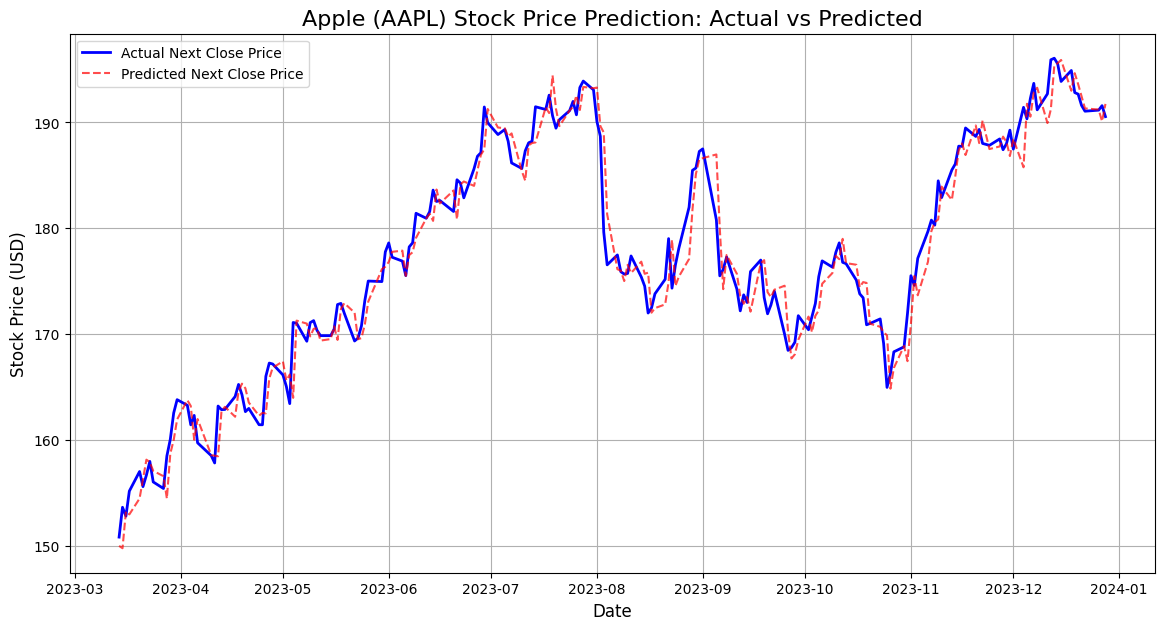

In [5]:
# Plot actual vs predicted closing prices
plt.figure(figsize=(14, 7))

# Plotting the actual next close prices
plt.plot(y_test.index, y_test.values, label='Actual Next Close Price', color='blue', linewidth=2)

# Plotting the predicted next close prices
plt.plot(y_test.index, predictions, label='Predicted Next Close Price', color='red', linestyle='dashed', alpha=0.7)

plt.title("Apple (AAPL) Stock Price Prediction: Actual vs Predicted", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Stock Price (USD)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### Final Insights
1. **Model Performance:** The Linear Regression model tracked the actual stock prices very closely, as seen in the visualization.
2. **Trend vs Reality:** While the model successfully captured the overall trend and general direction of the stock, predicting exact daily volatility remains challenging due to the unpredictable nature of financial markets.
3. **Features:** 'Open', 'High', 'Low', and 'Volume' are strong predictors for the immediate next day's close, acting as highly correlated features in short-term forecasting.